## Marketing Analytics Project Assignment 

End-to-end project homework notebook. 
In this project, each section calls into the `src/` modules so the notebook and the standalone scripts present inside the src folder (`python src/main.py`) stay in sync -- edit the logic in `src/`, re-run cells here to see results.

In [3]:
import sys
from pathlib import Path

root = Path.cwd()
candidates = [root / "src", root.parent / "src"]

for candidate in candidates:
    if (candidate / "scenarios.py").exists():
        sys.path.insert(0, str(candidate))
        break

import scenarios
import preprocessing
import eda
import roi
import shap_analysis

## Task 1 & 2 - Data Loading, EDA, and Preparation

Loads the raw Conjura CSV, filters to the selected organisation/territory (see `src/config.py` for the selection + justification), engineers media, control, and time features, and handles missing values.

In [5]:
clean_df = preprocessing.run_pipeline()
train_df, val_df = preprocessing.train_val_split(clean_df) #load the data and split into train and validation sets
clean_df.head()

[preprocessing] Interpolated 0 missing 'ALL_PURCHASES' values.
[preprocessing] Clean dataset: 1610 rows, 63 cols
[preprocessing] Saved to D:\Milano Bicocca\4th Semester\Marketing\PROJECT\project_mmm_meridian\project\data\mmm_modeling_dataset.csv


,DATE_DAY,MMM_TIMESERIES_ID,ORGANISATION_ID,ORGANISATION_VERTICAL,ORGANISATION_SUBVERTICAL,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,CURRENCY_CODE,FIRST_PURCHASES,...,meta_facebook_spend,google_paid_search_impressions,google_shopping_impressions,google_pmax_impressions,meta_facebook_impressions,discount_rate,day_of_week,month,is_weekend,trend
0,2020-01-06,51c8843bddcc604ebb3fe8d638ee5a1d,ba773ebd7ec0a08f1d042187d086ccb4,Business & Industrial,Business Services,"Google, Meta",UK,All Territories,GBP,332,...,0.0,2342.0,527090.0,0.0,0.0,0.074192,0,1,0,0
1,2020-01-07,51c8843bddcc604ebb3fe8d638ee5a1d,ba773ebd7ec0a08f1d042187d086ccb4,Business & Industrial,Business Services,"Google, Meta",UK,All Territories,GBP,363,...,0.0,3425.0,434022.0,0.0,0.0,0.071718,1,1,0,1
2,2020-01-08,51c8843bddcc604ebb3fe8d638ee5a1d,ba773ebd7ec0a08f1d042187d086ccb4,Business & Industrial,Business Services,"Google, Meta",UK,All Territories,GBP,359,...,0.0,3615.0,441619.0,0.0,0.0,0.073592,2,1,0,2
3,2020-01-09,51c8843bddcc604ebb3fe8d638ee5a1d,ba773ebd7ec0a08f1d042187d086ccb4,Business & Industrial,Business Services,"Google, Meta",UK,All Territories,GBP,329,...,0.0,3467.0,451507.0,0.0,0.0,0.095512,3,1,0,3
4,2020-01-10,51c8843bddcc604ebb3fe8d638ee5a1d,ba773ebd7ec0a08f1d042187d086ccb4,Business & Industrial,Business Services,"Google, Meta",UK,All Territories,GBP,341,...,0.0,3294.0,408460.0,0.0,0.0,0.081480,4,1,0,4


In [6]:
eda.run_eda() # Run the EDA notebook to generate visualizations and summary statistics

[eda] Missing values:
 None remaining after preprocessing.
[eda] Detected 28 outlier day(s) in ALL_PURCHASES (|z| > 3.0).

[eda] Spend concentration (%):
 google_shopping_spend       81.1
google_pmax_spend           12.3
meta_facebook_spend          3.5
google_paid_search_spend     3.0
dtype: float64

[eda] Avg purchases by day of week:
 DATE_DAY
Friday       670.8
Monday       680.8
Saturday     656.8
Sunday       735.8
Thursday     609.7
Tuesday      632.0
Wednesday    618.9
Name: ALL_PURCHASES, dtype: float64

[eda] Charts saved to D:\Milano Bicocca\4th Semester\Marketing\PROJECT\project_mmm_meridian\project\outputs\charts
[eda] Tables saved to D:\Milano Bicocca\4th Semester\Marketing\PROJECT\project_mmm_meridian\project\outputs\tables


### EDA charts (rendered inline)

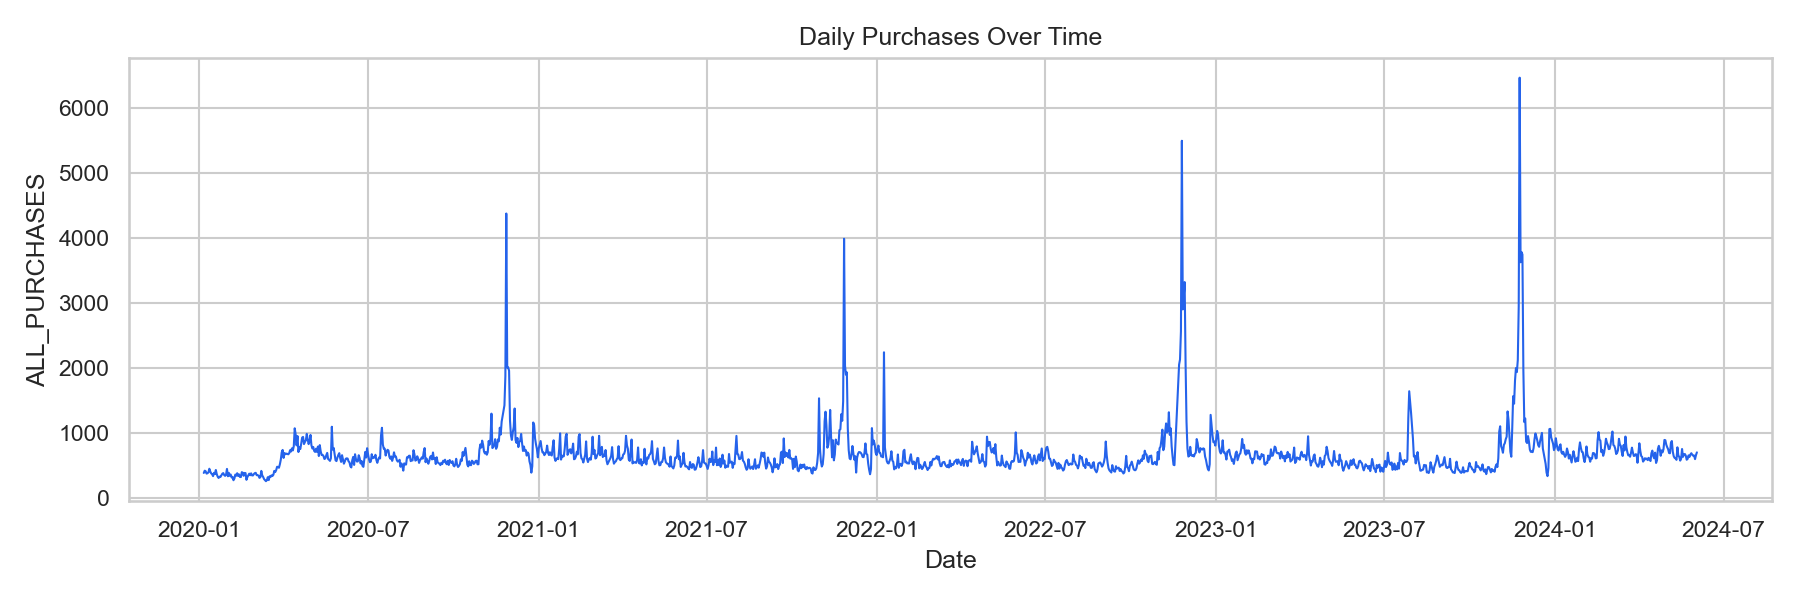

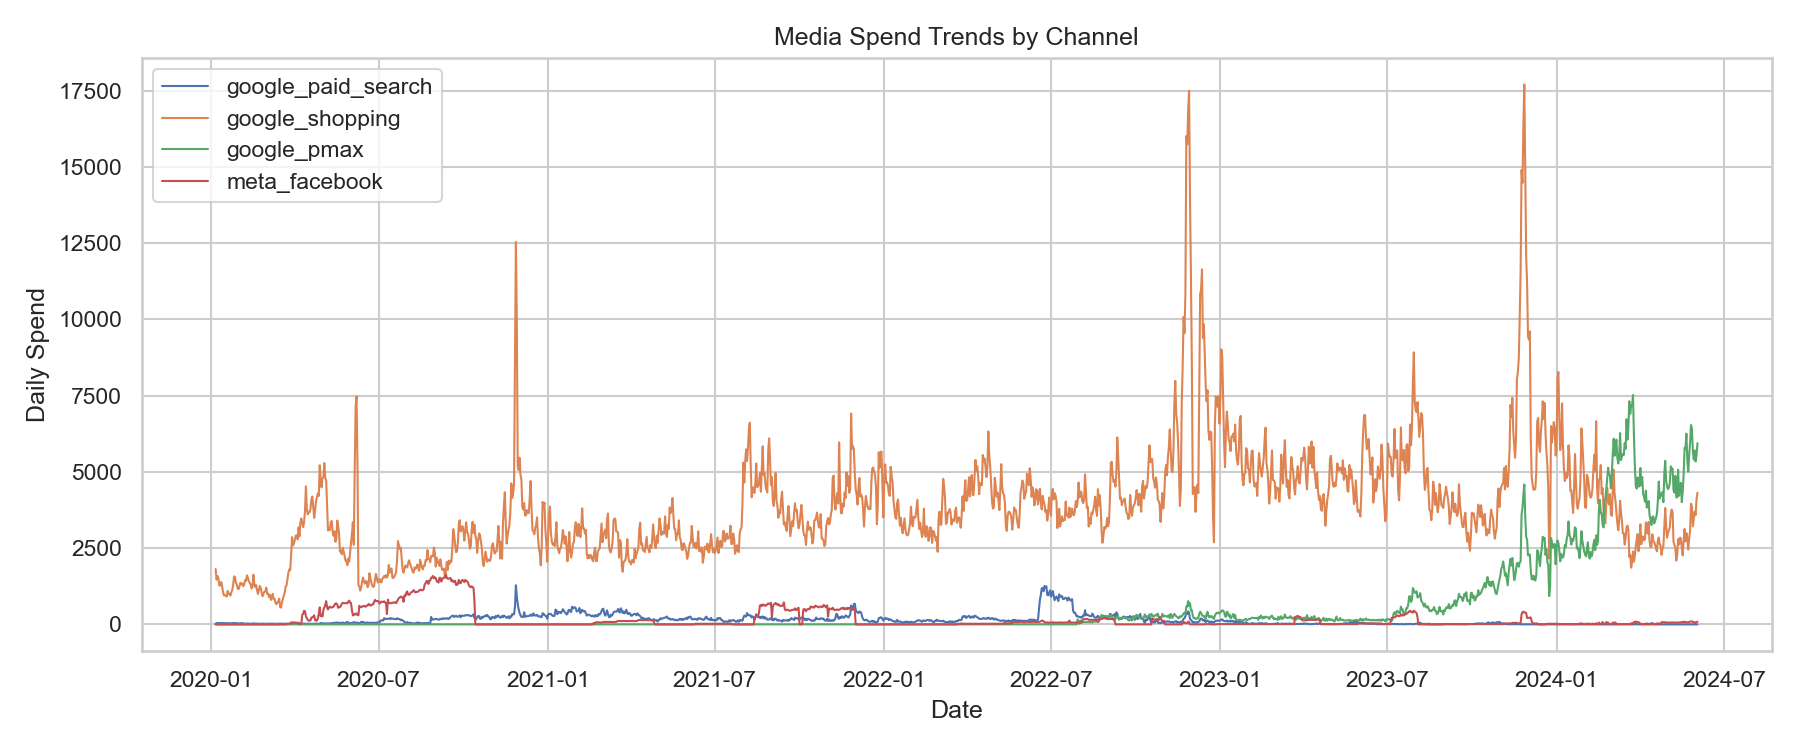

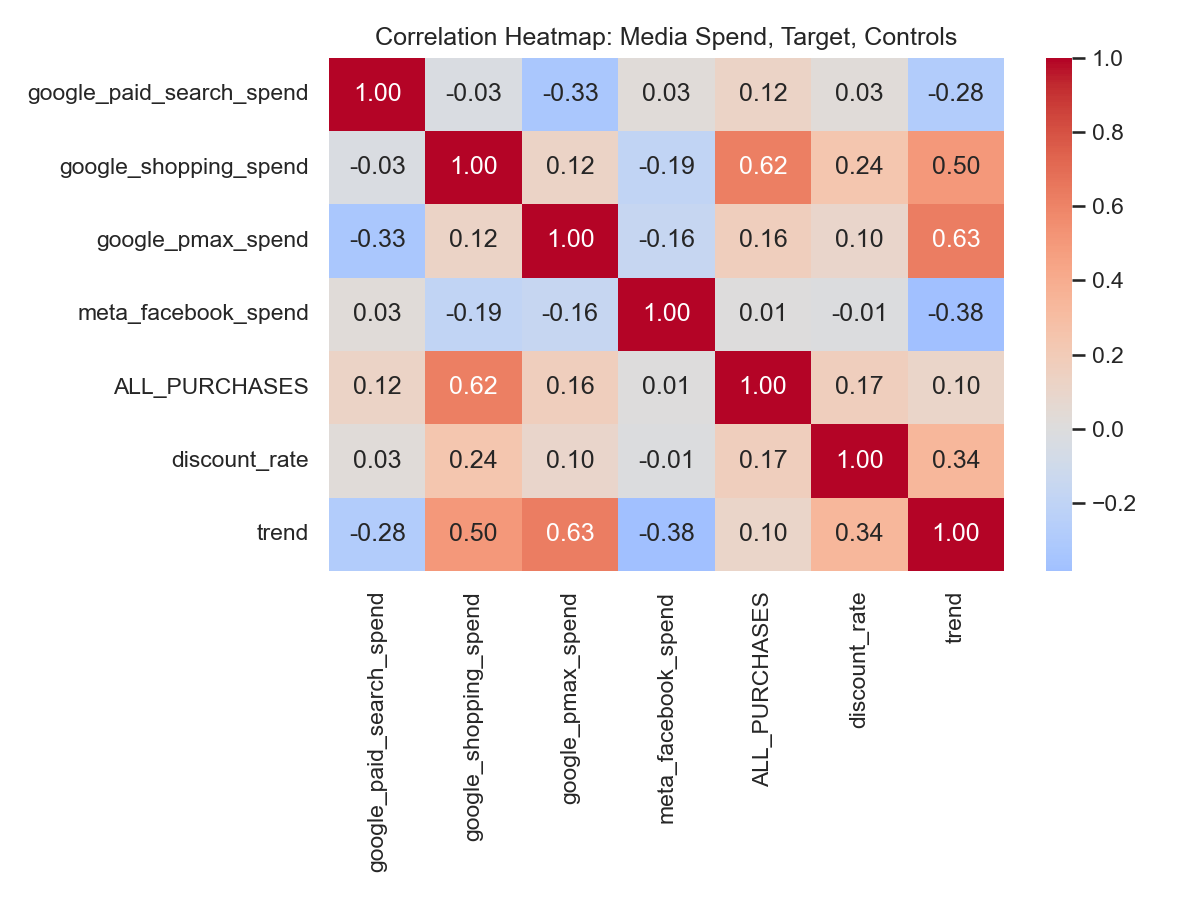

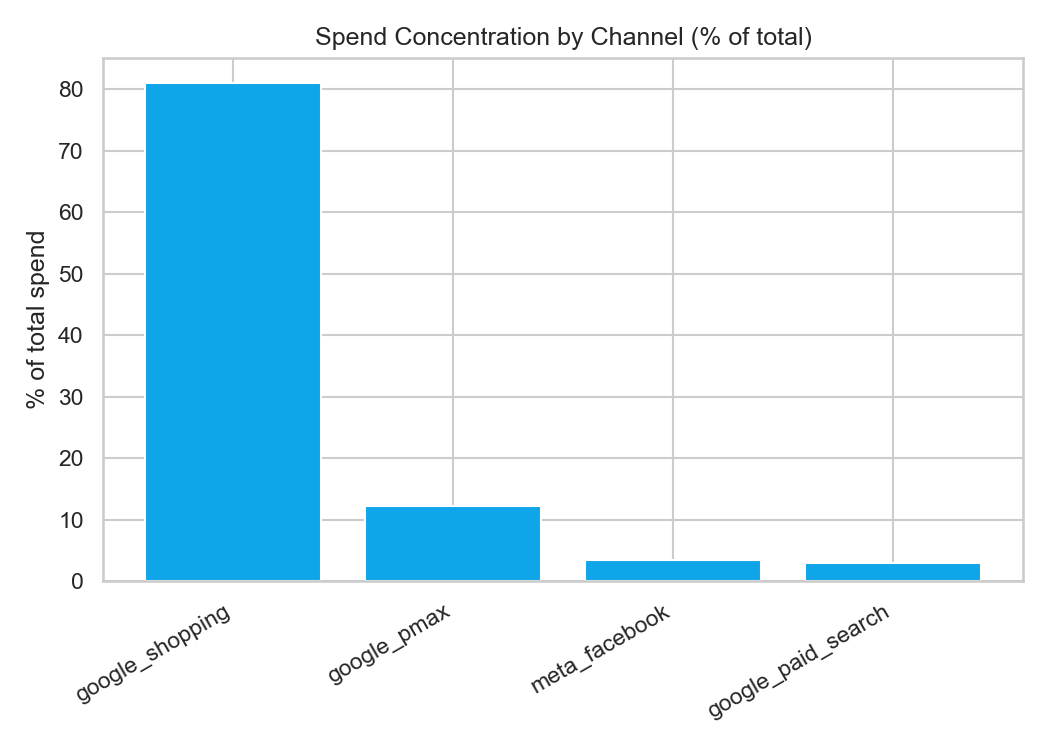

In [7]:
from IPython.display import Image, display
for f in ['daily_purchases.png', 'media_spend_trends.png', 'correlation_heatmap.png', 'spend_concentration.png']:
    display(Image(filename=str(eda.CHARTS_DIR / f)))

## Task 3 - Meridian MMM Model Development

Builds the national (single-geo) Meridian `InputData`, configures the model spec (ROI prior + knots), and fits with MCMC. **This step is slow** -- the default settings in `src/modeling.py` (`N_CHAINS`, `N_ADAPT`, `N_BURNIN`, `N_KEEP`) are intentionally modest for a quick first run; increase them for your final report.

In [8]:
mmm = modeling.run()

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\data\input_data_builder.py:715: UserWarning: The `population` argument is ignored in a nationally aggregated model. It will be reset to [1, 1, ..., 1]
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\data\input_data.py:525: UserWarning: Consider setting custom priors, as kpi_type was specified as `non_revenue` with no `revenue_per_kpi` being set. Otherwise, the total media contribution prior will be used with `p_mean=0.4` and `p_sd=0.2`. Further documentation available at https://developers.google.com/meridian/docs/advanced-modeling/unknown-revenue-kpi-custom#set-total-paid-media-contribution-prior
  warnings.warn(


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\model\context.py:760: UserWarning: Consider setting custom ROI priors, as kpi_type was specified as `non_revenue` with no `revenue_per_kpi` being set. Otherwise, the total media contribution prior will be used with `p_mean=0.4` and `p_sd=0.2`. Further documentation available at  https://developers.google.com/meridian/docs/advanced-modeling/unknown-revenue-kpi-custom#set-total-paid-media-contribution-prior
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\model\model.py:103: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\model\prior_distribution.py:1329: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Determ

[modeling] Fit metrics: {'R2': 0.8235560059547424, 'MAPE': 0.14888545870780945, 'RMSE': 155.5228329297663}


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:359: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:359: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:2700: UserWarning: Effectiveness is not reported because it does not have a clear interpretation by time period.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:

[modeling] Skipped Hill-curve plot: 'dict' object has no attribute 'save'
[modeling] Fitted model pickled to outputs/fitted_meridian_model.pkl


Fit metrics (R2 / MAPE / RMSE) and channel contribution / saturation curves are saved to `outputs/tables/` and `outputs/charts/` by the cell above.

## Task 4 - ROI and Marginal ROI Analysis

In [9]:
roi_df = roi.run()
roi_df

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:359: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


[roi] ROI / mROI table:
               channel  roi_mean   roi_std  mroi_mean  mroi_std  \
0     google_shopping  0.082457  0.008792   0.061403  0.006506   
1  google_paid_search  0.085752  0.064707   0.032550  0.025906   
2         google_pmax  0.067199  0.028384   0.027565  0.013480   
3       meta_facebook  0.062507  0.030493   0.017150  0.008886   

   vs_portfolio_avg_roi          investment_status  
0             -0.013076               near-optimal  
1             -0.041928  over-invested (saturated)  
2             -0.046913  over-invested (saturated)  
3             -0.057328  over-invested (saturated)  
[roi] Saved to D:\Milano Bicocca\4th Semester\Marketing\PROJECT\project_mmm_meridian\project\outputs\tables\roi_mroi_investment_status.csv


,channel,roi_mean,roi_std,mroi_mean,mroi_std,vs_portfolio_avg_roi,investment_status
0,google_shopping,0.082457,0.008792,0.061403,0.006506,-0.013076,near-optimal
1,google_paid_search,0.085752,0.064707,0.032550,0.025906,-0.041928,over-invested (saturated)
2,google_pmax,0.067199,0.028384,0.027565,0.013480,-0.046913,over-invested (saturated)
3,meta_facebook,0.062507,0.030493,0.017150,0.008886,-0.057328,over-invested (saturated)


## Task 5 - SHAP Explainability

SHAP is applied to a surrogate Gradient Boosting model trained on the same features (Meridian's Bayesian posterior isn't a plain `predict()` function SHAP can query) -- see the docstring in `src/shap_analysis.py`.

In [10]:
shap_analysis.run()

[shap] Surrogate GradientBoostingRegressor holdout R2 = -3.701
[shap] NOTE: negative holdout R2 on a pure chronological (last-20%) split is common here -- 2024 is a partial, less volatile year, so the model is extrapolating rather than interpolating. This does not invalidate the SHAP explanations (they describe what the model learned from the training distribution), but you should discuss this limitation in your report. Options to improve it: try a log(target) transform, a blocked/rolling-origin CV instead of one holdout, or fewer estimators/shallower trees.


PermutationExplainer explainer: 1611it [02:05, 12.48it/s]                          
d:\Milano Bicocca\4th Semester\Marketing\PROJECT\project_mmm_meridian\project\src\shap_analysis.py:101: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


[shap] Feature importance:
                      feature  mean_abs_shap
4      ORGANIC_SEARCH_CLICKS     302.177157
7            REFERRAL_CLICKS      78.572466
9                      trend      58.789585
6               EMAIL_CLICKS      36.073696
1      google_shopping_spend      28.734720
2          google_pmax_spend      21.320818
11                     month      19.245690
5      BRANDED_SEARCH_CLICKS      19.013138
10               day_of_week       8.785637
8              discount_rate       7.273298
0   google_paid_search_spend       3.860027
3        meta_facebook_spend       3.520886
12                is_weekend       0.001290
[shap] SHAP vs MMM comparison:
               channel  mean_abs_shap  shap_rank
1     google_shopping      28.734720        1.0
2         google_pmax      21.320818        2.0
0  google_paid_search       3.860027        3.0
3       meta_facebook       3.520886        4.0
[shap] Charts saved to D:\Milano Bicocca\4th Semester\Marketing\PROJECT\project_mmm_

## Task 6 - Marketing Investment Scenario Simulation

In [11]:
scenario_df = scenarios.run()
scenario_df

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:359: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:359: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:359: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:359: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\s

[scenarios] Historical baseline incremental outcome: 613581.3125
[scenarios] Scenario comparison:
            Scenario  Incremental Outcome (Purchases)  \
0  Equal allocation                     332187.15625   
1    mROI optimized                     626163.93750   
2  Saturation-aware                     616882.68750   

   Incremental vs Historical Baseline       ROI  
0                       -281394.15625  0.043299  
1                         12582.62500  0.081627  
2                          3301.37500  0.080407  
[scenarios] Saved to D:\Milano Bicocca\4th Semester\Marketing\PROJECT\project_mmm_meridian\project\outputs\tables\scenario_comparison.csv


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:359: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\meridian\analysis\analyzer.py:359: UserWarning: Revenue analysis is not available when `revenue_per_kpi` is unknown. Defaulting to KPI analysis.
  warnings.warn(


,Scenario,Incremental Outcome (Purchases),Incremental vs Historical Baseline,ROI
0,Equal allocation,332187.15625,-281394.15625,0.043299
1,mROI optimized,626163.93750,12582.62500,0.081627
2,Saturation-aware,616882.68750,3301.37500,0.080407


## Final Questions

**1. Based on your Meridian MMM model, what is your recommended marketing investment strategy for the next quarter, and why?**

For the next quarter, keep the current budget strategy and make only small changes instead of major adjustments.

- Must increase Google Shopping spending slightly, as it delivers the best results and still has ability to grow.
- We can improve Meta by reducing Meta (Facebook) spending because it performs the weakest.
- Must keep Google PMax budget unchanged since there is not enough historical data for evaluating it in proper way.
- Before investing huge amount, test Google Paid Search with a small budget, as its performance estimatins are so far uncertain.

Recommended action: Shift about 30% of Meta's budget to Google Shopping. This is a low-risk change that is expected to increase purchases without increasing the total advertising budget.

Also, it has been notices that sales usually peak in November, so allocating more budget to Google Shopping before the holiday season is likely to give the best return.

**2. Define the best strategy toward revenue maximization.**

In actual, this model predicts the number of purchases, not the actual revenue. In most cases, more purchases indictaes more revenue, but this may sounds wrong if some channels sell higher-priced products than others.

The best strategy is to gradually shift budget from the weakest-performing channel to the strongest-performing one. Based on the results from this project we can say that it would be the best to move budget from Meta to Google Shopping for the most effective improvement.

For future budget decisions:

- Must test Paid Search and Performance Max (PMax) with smaller campaigns before increasing their budgets, as their estimates are less certain.
- Also, include sales value or profit data in future models to optimize for revenue instead of only the number of purchases. If product values are similar across channels, the current budget recommendation should also improve revenue.